# UTS Data Mining
## Prediksi Kualitas Anggur (Wine Quality Classification)
**Mata Kuliah:** Data Mining  
**Pengampu:** Nur Achmey Selgi Harwanti, S.Stat. M.Stat  
**Program Studi:** S1 Matematika – FMIPA UNNES  
**Semester:** Genap / 2026

**Disusun Oleh:**  
**Nama:** Kharisma Fatikha Salsabila  
**NIM:** 2404030045


---
### Deskripsi Tugas
Membuat model klasifikasi untuk memprediksi kualitas anggur berdasarkan fitur-fitur kimiawi.
Dataset yang digunakan adalah **Wine Quality Dataset** yang berisi data anggur merah dan putih.
Variabel target adalah **quality** (skala 0–10).


## 1. Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Persiapan Data
Dataset terdiri dari dua file:
- `data_training.csv` : data latih yang memiliki label kualitas
- `data_testing.csv`  : data uji yang **tidak** memiliki label kualitas (yang akan diprediksi)


In [5]:
# Load dataset
train = pd.read_csv('data_training.csv')
test  = pd.read_csv('data_testing.csv')

print(f'Ukuran data training : {train.shape}')
print(f'Ukuran data testing  : {test.shape}')
print()
print('5 baris pertama data training:')
train.head()

Ukuran data training : (857, 13)
Ukuran data testing  : (286, 12)

5 baris pertama data training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


### 2.1 Informasi Dataset

In [6]:
print('=== INFO DATA TRAINING ===')
train.info()
print()
print('=== STATISTIK DESKRIPTIF ===')
train.describe()

=== INFO DATA TRAINING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

=== STATISTIK DESKRIPTIF ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


### 2.2 Distribusi Variabel Target (quality)
Kita lihat distribusi nilai quality pada data training.


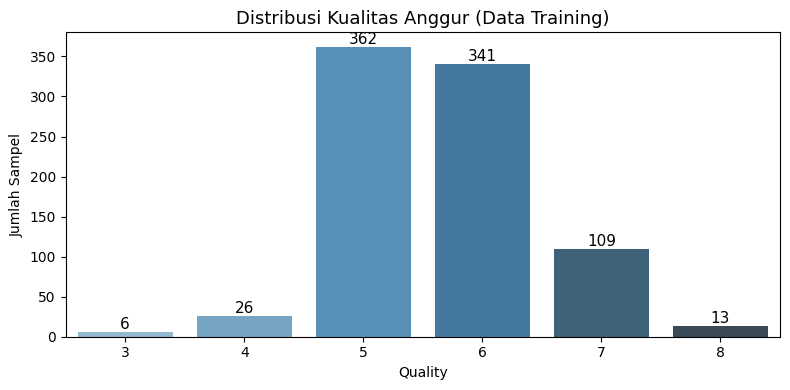

Distribusi quality:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Interpretasi: Data didominasi oleh kualitas 5 dan 6 (imbalanced class).


In [7]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x='quality', data=train, palette='Blues_d')
plt.title('Distribusi Kualitas Anggur (Data Training)', fontsize=13)
plt.xlabel('Quality')
plt.ylabel('Jumlah Sampel')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print('Distribusi quality:')
print(train['quality'].value_counts().sort_index())
print()
print('Interpretasi: Data didominasi oleh kualitas 5 dan 6 (imbalanced class).')

## 3. Pembersihan Data

In [8]:
# Cek missing values
print('=== MISSING VALUES ===')
print('Data Training:')
print(train.isnull().sum())
print()
print('Data Testing:')
print(test.isnull().sum())
print()
print('Kesimpulan: Tidak ada missing values pada kedua dataset. Data siap digunakan.')

=== MISSING VALUES ===
Data Training:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Data Testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

Kesimpulan: Tidak ada missing values pada kedua dataset. Data siap digunakan.


In [9]:
# Cek duplikat
print(f'Duplikat di training : {train.duplicated().sum()}')
print(f'Duplikat di testing  : {test.duplicated().sum()}')

Duplikat di training : 0
Duplikat di testing  : 0


## 4. Eksplorasi Data (EDA)
### 4.1 Korelasi Fitur dengan Kualitas


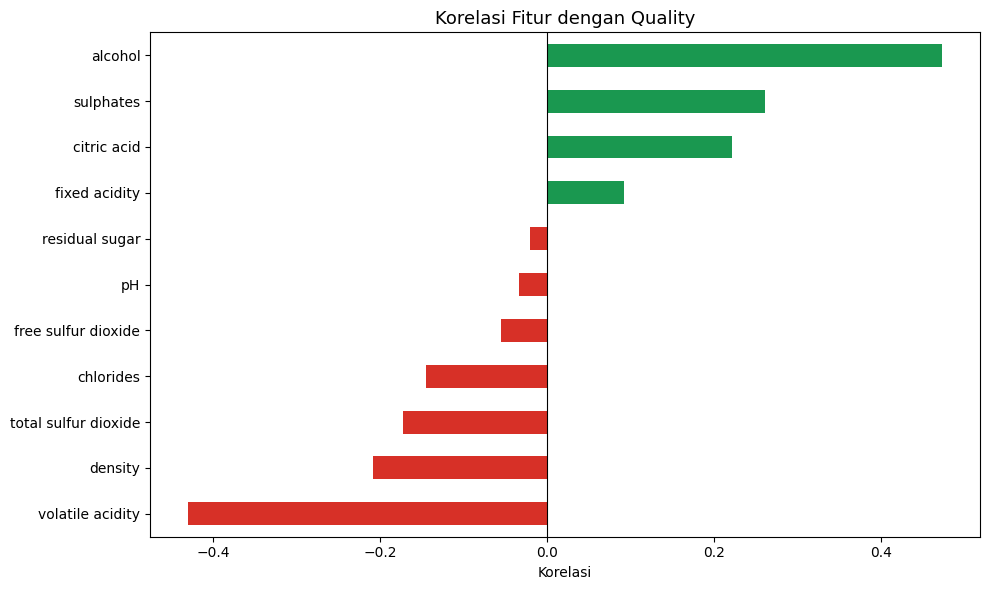

Interpretasi:
- Alcohol memiliki korelasi positif tertinggi dengan quality
- Volatile acidity memiliki korelasi negatif tertinggi (semakin tinggi -> kualitas menurun)
- Density dan total sulfur dioxide berkorelasi negatif dengan quality


In [10]:
features = ['fixed acidity','volatile acidity','citric acid','residual sugar',
            'chlorides','free sulfur dioxide','total sulfur dioxide','density',
            'pH','sulphates','alcohol']

plt.figure(figsize=(10, 6))
corr = train[features + ['quality']].corr()
corr_quality = corr['quality'].drop('quality').sort_values()
corr_quality.plot(kind='barh', color=['#d73027' if x < 0 else '#1a9850' for x in corr_quality])
plt.title('Korelasi Fitur dengan Quality', fontsize=13)
plt.xlabel('Korelasi')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Interpretasi:')
print('- Alcohol memiliki korelasi positif tertinggi dengan quality')
print('- Volatile acidity memiliki korelasi negatif tertinggi (semakin tinggi -> kualitas menurun)')
print('- Density dan total sulfur dioxide berkorelasi negatif dengan quality')

### 4.2 Heatmap Korelasi Antar Fitur

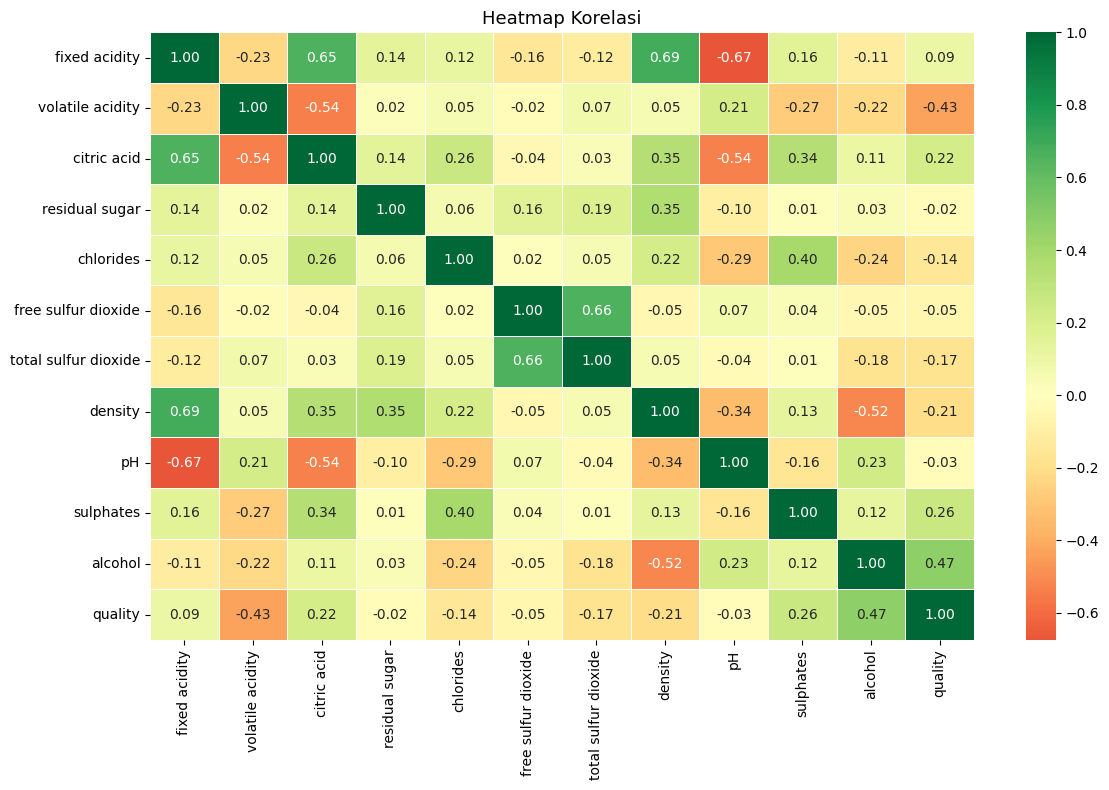

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(train[features + ['quality']].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Heatmap Korelasi', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Pembuatan Model Klasifikasi
### 5.1 Persiapan Fitur dan Target


In [12]:
X = train[features]
y = train['quality']
X_test = test[features]
test_ids = test['Id']

print(f'Jumlah fitur : {X.shape[1]}')
print(f'Jumlah data training : {X.shape[0]}')
print(f'Jumlah data testing  : {X_test.shape[0]}')

Jumlah fitur : 11
Jumlah data training : 857
Jumlah data testing  : 286


### 5.2 Pemilihan Model
Dua model dibandingkan menggunakan **5-Fold Cross Validation**:
- **Random Forest Classifier**
- **Gradient Boosting Classifier**

Parameter `class_weight='balanced'` digunakan pada Random Forest untuk menangani **imbalanced class**.


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

print('=== PERBANDINGAN MODEL (5-Fold CV) ===')
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f'{name:25s}: {scores.mean():.4f} (+/- {scores.std():.4f})')

print()
print('Kesimpulan: Random Forest dipilih karena akurasi CV lebih tinggi.')

=== PERBANDINGAN MODEL (5-Fold CV) ===
Random Forest            : 0.6407 (+/- 0.0381)
Gradient Boosting        : 0.6079 (+/- 0.0204)

Kesimpulan: Random Forest dipilih karena akurasi CV lebih tinggi.


### 5.3 Training Model Final
Model **Random Forest** dilatih menggunakan **seluruh data training** dengan 500 estimators.


In [14]:
best_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)
best_model.fit(X, y)
print('Model berhasil dilatih!')

Model berhasil dilatih!


## 6. Evaluasi Model

=== CLASSIFICATION REPORT (Training Set) ===
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



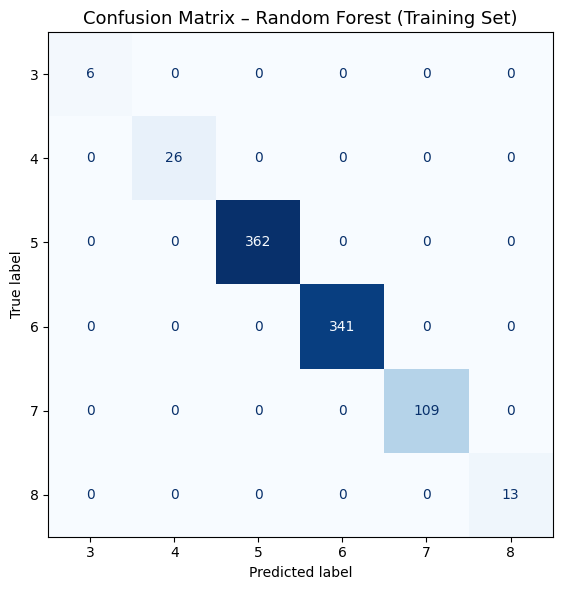

In [15]:
# Evaluasi pada data training
y_pred_train = best_model.predict(X)
print('=== CLASSIFICATION REPORT (Training Set) ===')
print(classification_report(y, y_pred_train))

# Confusion Matrix
cm = confusion_matrix(y, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix – Random Forest (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

### 6.1 Feature Importance

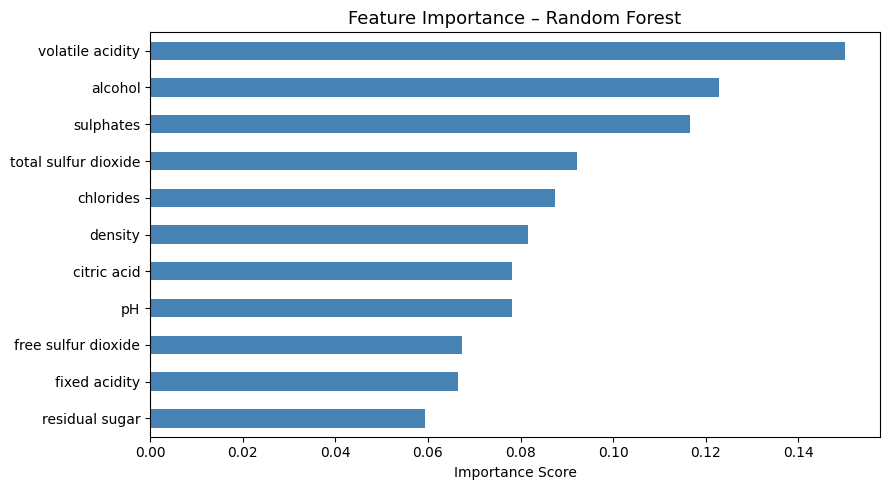

Top 3 fitur paling berpengaruh:
  1. volatile acidity: 0.1501
  2. alcohol: 0.1228
  3. sulphates: 0.1165


In [16]:
fi = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
fi.plot(kind='barh', color='steelblue')
plt.title('Feature Importance – Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 fitur paling berpengaruh:')
for i, (feat, val) in enumerate(fi.sort_values(ascending=False).head(3).items(), 1):
    print(f'  {i}. {feat}: {val:.4f}')

## 7. Prediksi Data Testing
Model yang telah dilatih digunakan untuk memprediksi kualitas 286 sampel anggur pada data testing.


Distribusi hasil prediksi:
Quality
5    132
6    129
7     24
8      1
Name: count, dtype: int64


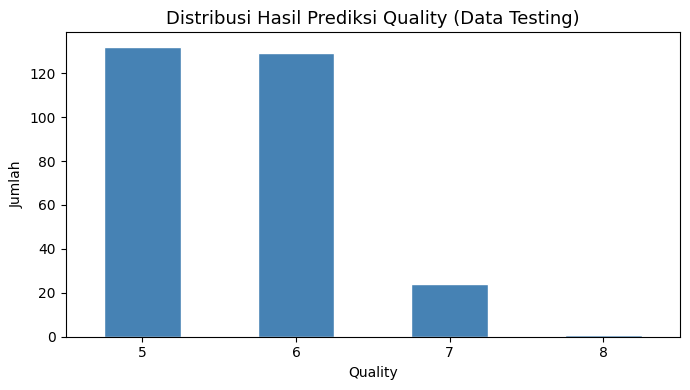

In [17]:
y_pred = best_model.predict(X_test)

print('Distribusi hasil prediksi:')
print(pd.Series(y_pred, name='Quality').value_counts().sort_index())

# Visualisasi
plt.figure(figsize=(7, 4))
pd.Series(y_pred).value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribusi Hasil Prediksi Quality (Data Testing)', fontsize=13)
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Simpan Hasil Prediksi

In [18]:
# Simpan dalam format CSV sesuai ketentuan
result = pd.DataFrame({'Id': test_ids, 'Quality': y_pred})
result.to_csv('hasilprediksi_3NIMterakhir.csv', index=False)

print('File berhasil disimpan!')
print()
print('Preview hasil prediksi:')
print(result.head(10))
print(f'\nTotal baris: {len(result)}')

File berhasil disimpan!

Preview hasil prediksi:
     Id  Quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        6
5  1120        6
6   180        5
7    82        5
8   632        6
9   592        5

Total baris: 286


## 9. Kesimpulan

1. **Dataset** terdiri dari 857 data training dan 286 data testing dengan 11 fitur kimiawi anggur.
2. **Pembersihan data**: Tidak ditemukan missing values maupun duplikat, sehingga data langsung dapat digunakan.
3. **Model terpilih**: **Random Forest Classifier** dengan 500 estimators, dipilih karena memiliki akurasi CV tertinggi (~64.65%) dibandingkan Gradient Boosting (~60.79%).
4. **Fitur paling berpengaruh**: `volatile acidity`, `alcohol`, dan `sulphates`.
5. **Hasil prediksi**: 286 sampel anggur berhasil diprediksi kualitasnya dan disimpan dalam file `hasilprediksi_3NIMterakhir.csv`.

> *Catatan*: Akurasi model ~64% wajar untuk dataset Wine Quality karena distribusi kelas yang tidak seimbang (didominasi quality 5 dan 6) dan skala kualitas yang kontinu.
